In [1]:
# June 2026 rotation flights

In [2]:
## First import general packages for running python analysis:
import os, h5py, datetime,pytz,pickle, yaml, sys
import numpy as np
from matplotlib.pyplot import *
from matplotlib import pyplot as plt

## Then import the beamcals module, use forked repository (not original):
sys.path.insert(0, '../classes/')
import corr, concat, drone
import plotting_utils as pu
import fitting_utils as fu
import geometry_utils as gu
import time_utils as tu
import site_utils as si
import reduce as rc
gbosite=si.Site('../metadata/GBO_DNS_config.npz')

# Define any channels, etc, and directories for this flight analysis

#config_directory="  "
maindir = '/hirax/DNS_freespace/2026_07_GBO/'
dronedir = maindir+'processed_flight_records/'
cdir = maindir+'TONE_crs_files/' # correlator file dir
gdir = cdir+'gains/' # gain dir 

# define which channels in the data files are useful
#crmap = [0,3,4,6,7,8,9]
#chnames = ['EW_D5_auto','EW_D5_cr','NS_D5_auto','NS_D5_cr','NS_D8_auto','NS_D8_cr','ref_auto']

## from crmap, which indices are autos, which indices are ref crosses
#autos = [0,2,4,6]
#crosses = [1,3,5]


## define default 'good' frequency for plotting
f_ind = 1000
#freqs = np.arange(800,400,-400./1024)
#print(freqs[f_ind])

###################
#### FUNCTIONS ####
###################

def get_mag_phase(power0):
    """
    # return magnitude and phase in degrees of correlations
    """
    return np.absolute(power0), np.rad2deg(np.angle(power0))

In [3]:
july2025=False

# July 2025 flights (corrupted by 10MHz RFI)

if july2025:
    ## First import general packages for running python analysis:

    gbosite=si.Site('../metadata/GBO_DNS_config.npz')
    
    # Define any channels, etc, and directories for this flight analysis

    #config_directory="  "
    maindir = '/hirax/DNS_freespace/TONE_july_2025/'
    dronedir = maindir+'processed_flight_records/'
    cdir = maindir+'TONE_iceboard_files/corr_data/'
    gdir = gdir+'TONE_iceboard_files/digital_gains/' 

    # define which channels in the data files are useful
    crmap = [0,3,4,6,7,8,9]
    chnames = ['EW_D5_auto','EW_D5_cr','NS_D5_auto','NS_D5_cr','NS_D8_auto','NS_D8_cr','ref_auto']

    # from crmap, which indices are autos, which indices are ref crosses
    autos = [0,2,4,6]
    crosses = [1,3,5]


    # define default 'good' frequency for plotting
    f_ind = 304 
    freqs = np.arange(800,400,-400./1024)
    print(freqs[f_ind])





In [4]:
gbosite=si.Site('../metadata/GBO_DNS_config.npz')

# First 360 degree, lots of locations
ddir = 'first_drone_jun30_0900/'
flyfile = 'Jun-30th-2026-09-09AM-Flight-Airdata.csv'


# this handles the wierd directory structure in the iceboard dirs
datadir = cdir+ddir
gfile = gdir+'20260630-084913_gbo_gains_chord_path_drone_first_jun30.npy' 

print(gfile)


/hirax/DNS_freespace/2026_07_GBO/TONE_crs_files/gains/20260630-084913_gbo_gains_chord_path_drone_first_jun30.npy


Initializing drone data via Airdata.csv routine: Jun-30th-2026-09-09AM-Flight-Airdata.csv
  --> generating llh, geocentric cartesian, local cartesian, and local spherical coordinates.
  --> generating dish and receiver line of sight coordinates.


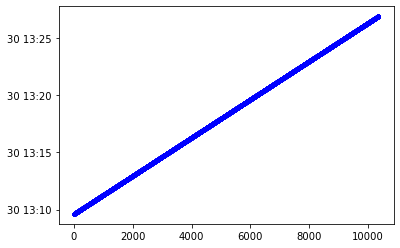

DRONE FLYING FROM (UTC):  2026-06-30 13:09:37+00:00  to (UTC)  2026-06-30 13:26:53.400000+00:00


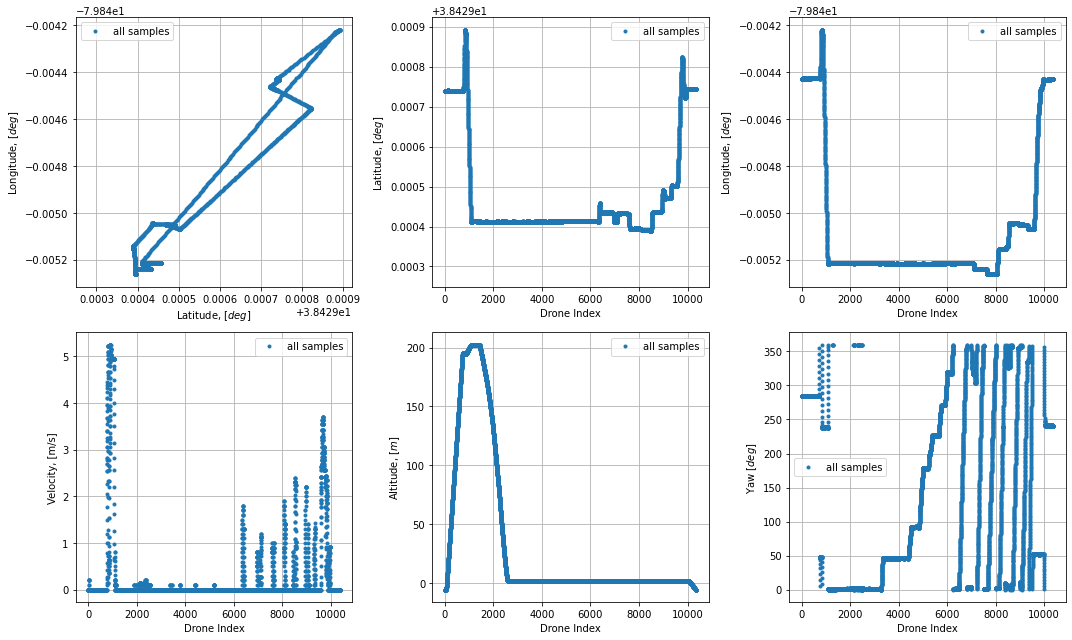

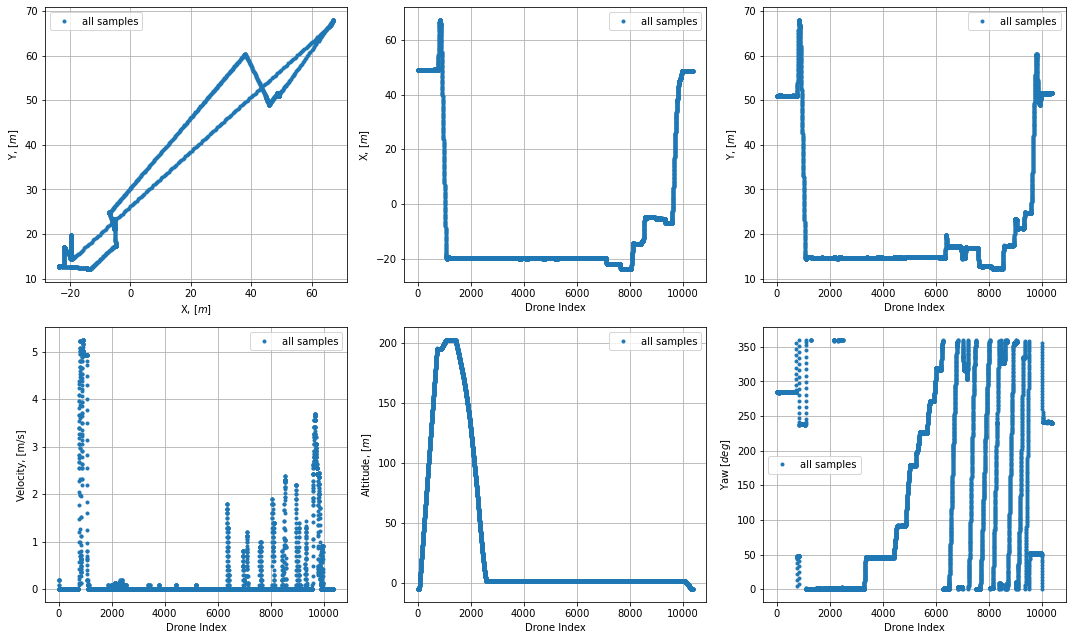

In [5]:
# read in drone flight

# Read in drone data

dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=flyfile,site_class=gbosite,tlb=0,tub=-1)

# Plot some drone data to get familiar with the coordinates in the drone class

# Look at time stamps

plt.plot(dronedata.t_arr_datetime,'b.',label='drone')
plt.show()

print('DRONE FLYING FROM (UTC): ', dronedata.t_arr_datetime[0], ' to (UTC) ',dronedata.t_arr_datetime[-1])


## Plot lat/long
fig1,[[ax1,ax2,ax3],[ax4,ax5,ax6]]=subplots(nrows=2,ncols=3,figsize=(15,9))
## Plot p0 coordinate origin:
ax1.plot(dronedata.origin[0],dronedata.origin[1],'ro')
ax2.axhline(dronedata.origin[0],c='b')
ax3.axhline(dronedata.origin[1],c='b')
## Title each coordinate subplot:        
ax1.set_title('Lat vs Lon')
ax2.set_title('Lat vs Time')
ax3.set_title('Lon vs Time')
ax4.set_title('Velocity vs Time')
ax5.set_title('Altitude vs Time')
ax6.set_title('Yaw vs Time')
## Specify arrays/vectors to plot in 1,3,4 coordinate subplot
xqtys=[dronedata.latitude,dronedata.t_index,dronedata.t_index,dronedata.t_index,dronedata.t_index,dronedata.t_index]
yqtys=[dronedata.longitude,dronedata.latitude,dronedata.longitude,dronedata.velocity,dronedata.altitude,dronedata.yaw]
xtags=['Latitude, [$deg$]','Drone Index','Drone Index','Drone Index','Drone Index','Drone Index']
ytags=['Longitude, [$deg$]','Latitude, [$deg$]','Longitude, [$deg$]','Velocity, [m/s]','Altitude, [$m$]','Yaw [$deg$]']
for i,ax in enumerate([ax1,ax2,ax3,ax4,ax5,ax6]):
    ax.plot(np.nanmin(xqtys[i]),np.nanmin(yqtys[i]))
    ax.plot(np.nanmax(xqtys[i]),np.nanmax(yqtys[i]))
    autoscalelims=ax.axis()
    ax.clear()
    ax.plot(xqtys[i],yqtys[i],'.',label='all samples')
    ax.set_xlabel(xtags[i])
    ax.set_ylabel(ytags[i])
    ax.grid()
    ax.legend()
    ax.set_xlim(autoscalelims[0],autoscalelims[1])
    ax.set_ylim(autoscalelims[2],autoscalelims[3])
tight_layout()
plt.show()

## Plot local X/Y coords
fig1,[[ax1,ax2,ax3],[ax4,ax5,ax6]]=subplots(nrows=2,ncols=3,figsize=(15,9))
## Plot p0 coordinate origin:
ax1.set_title('X vs Y')
ax2.set_title('X vs Time')
ax3.set_title('Y vs Time')
ax4.set_title('Velocity vs Time')
ax5.set_title('Altitude vs Time')
ax6.set_title('Yaw vs Time')
## Specify arrays/vectors to plot in 1,3,4 coordinate subplot
xqtys=[dronedata.coords_xyz_LC[:,0],dronedata.t_index,dronedata.t_index,dronedata.t_index,dronedata.t_index,dronedata.t_index]
yqtys=[dronedata.coords_xyz_LC[:,1],dronedata.coords_xyz_LC[:,0],dronedata.coords_xyz_LC[:,1],dronedata.velocity,dronedata.altitude,dronedata.yaw]
xtags=['X, [$m$]','Drone Index','Drone Index','Drone Index','Drone Index','Drone Index']
ytags=['Y, [$m$]','X, [$m$]','Y, [$m$]','Velocity, [m/s]','Altitude, [$m$]','Yaw [$deg$]']
for i,ax in enumerate([ax1,ax2,ax3,ax4,ax5,ax6]):
    ax.plot(np.nanmin(xqtys[i]),np.nanmin(yqtys[i]))
    ax.plot(np.nanmax(xqtys[i]),np.nanmax(yqtys[i]))
    autoscalelims=ax.axis()
    ax.clear()
    ax.plot(xqtys[i],yqtys[i],'.',label='all samples')
    ax.set_xlabel(xtags[i])
    ax.set_ylabel(ytags[i])
    ax.grid()
    ax.legend()
    ax.set_xlim(autoscalelims[0],autoscalelims[1])
    ax.set_ylim(autoscalelims[2],autoscalelims[3])
tight_layout()
plt.show()    

In [6]:


# This is the first time I'm looking at CRS board data, so ... might be wierd
# # Which channels are interesting?
fd=h5py.File(datadir+'7.hdf5', 'r')


# info in the file?
print(fd.keys())

print(fd['vis'].shape) # time, freq, product
print(fd['counts'].shape) # time
print(fd['sat']) # saturation map, same size as vis

item_names = list(fd['index_map'].keys())
print(item_names)

print(fd['index_map']['time'][0])
print(fd['index_map']['prod'][0])
print(fd['index_map']['freq'][0])

print(fd['index_map']['freq'][0:1024])


<KeysViewHDF5 ['counts', 'index_map', 'sat', 'vis']>
(1000, 8192, 36)
(1000,)
<HDF5 dataset "sat": shape (1000, 8192, 36), type "<c8">
['freq', 'prod', 'time']
1782825326.324152
[1 1]
0.0
[0.00000000e+00 1.95312500e-01 3.90625000e-01 ... 1.99414062e+02
 1.99609375e+02 1.99804688e+02]


(8, 8192)
0 0.027853755285745217
1 0.05619060779821427
2 0.031194568907656588
3 0.0032268262776873357
4 0.9947053376399628
5 0.9914065646299899
6 0.9831449918844312
7 0.9702869658666529


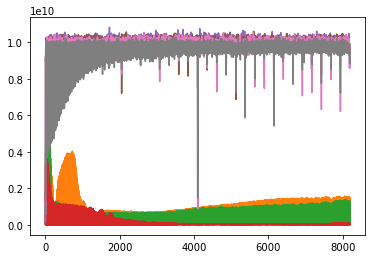

In [7]:
# let's load in gains and see what happens

gains = np.load(gfile)
print(gains.shape) # inputs, frequencies

for i in np.arange(0,8):
    plt.plot(gains[i,:],label=str(i))
    print(i, 1E-10*np.median(gains[i,:]))
plt.show()

# looks like 4 channels hookedup

In [8]:
# find channels with zero imag component, those are autos
#f_ind = 500
#for i in np.arange(0,36):
#    print(i, fd['vis'][200,f_ind,i].imag)

# autos from above, and crosses are everything else

autos = [0,4,8,12,16,20,24,28]
crosses = [item for item in np.arange(0,36) if item not in autos]

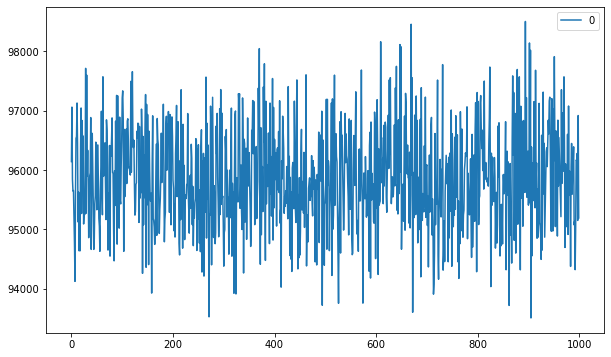

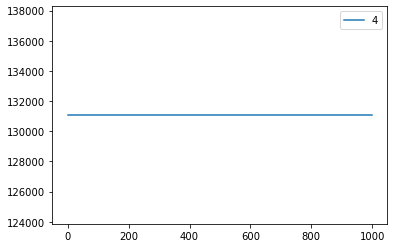

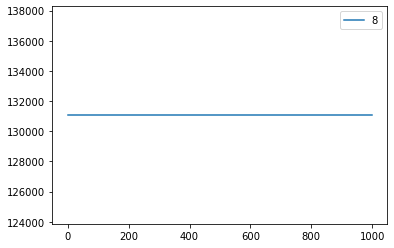

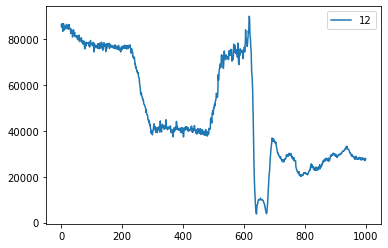

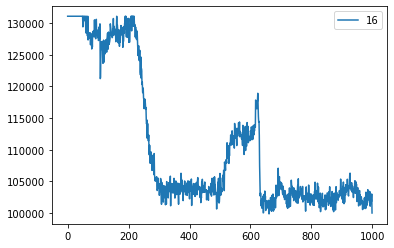

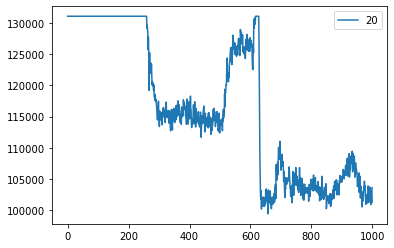

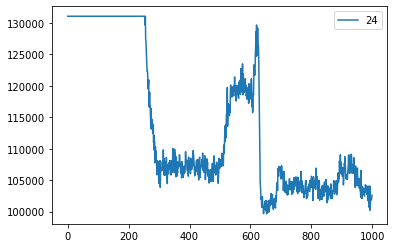

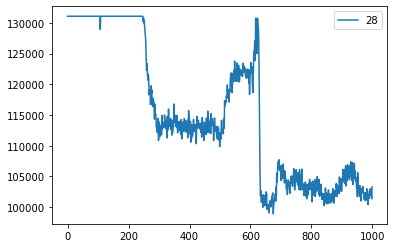

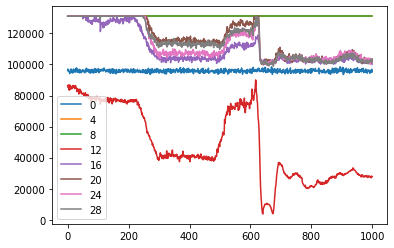

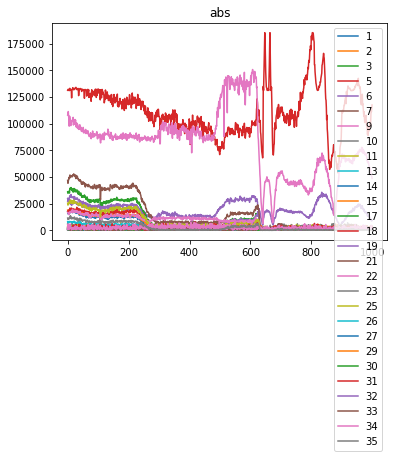

In [17]:

plt.figure(figsize=(10, 6))
for i in autos:
    plt.plot(abs(fd['vis'][:,f_ind,i]),label=str(i)) # both real and imag are informative
    plt.legend()
    plt.plot()
    plt.show()


for i in autos:
    #if np.median(abs(fd['vis'][:,f_ind,i])) > 20000:
        #plt.plot(fd['vis'][:,f_ind,i].real,label=str(i)) # both real and imag are informative
    plt.plot(fd['vis'][:,f_ind,i].real,label=str(i)) # both real and imag are informative
    #print(i, fd['vis'][200,f_ind,i].real)
plt.legend()
plt.show()

for i in crosses:
    #if np.median(abs(fd['vis'][:,f_ind,i])) > 20000:
        #plt.plot(fd['vis'][:,f_ind,i].real,label=str(i)) # both real and imag are informative
    plt.plot(abs(fd['vis'][:,f_ind,i]),label=str(i)) # both real and imag are informative
plt.title('abs')
plt.legend()    
plt.show()

Initializing Correlator Class using:
  --> /hirax/DNS_freespace/2026_07_GBO/TONE_crs_files/first_drone_jun30_0900/
  --> ERROR: CRS gain file not loaded: Gain_Directory is a directory (/hirax/DNS_freespace/2026_07_GBO/TONE_crs_files/gains/); CRS gain files are one-per-acquisition, not one-per-channel -- point Gain_Directory at the exact .npy file for this acquisition instead (e.g. gaindir = gdir + '<specific_file>.npy').
  --> Falling back to unity gains (Apply_Gains will be a no-op).
Assigning array values by reading in data files:
  --> Loading File 1/110.hdf5
  --> Loading File 2/111.hdf5
  --> Loading File 3/112.hdf5
  --> Loading File 4/113.hdf5
  --> Loading File 5/114.hdf5
  --> Loading File 6/115.hdf5
  --> Loading File 7/116.hdf5
  --> Loading File 8/117.hdf5
  --> Loading File 9/118.hdf5
  --> Loading File 10/119.hdf5
  --> Loading File 11/1110.hdf5

  --> Finished. Reshaping arrays.


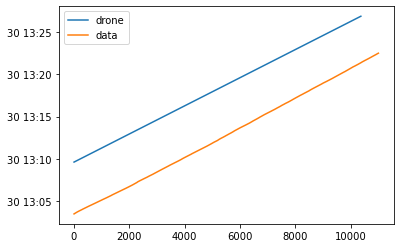

In [11]:
# now read in all files and try to get time offset
#corrdata=corr.Corr_Data_CRS_LBN(Data_Directory=datadir,Gain_Directory=gdir,
#                            site_class=gbosite, vinputs=[1,2,3])

corrdata=corr.Corr_Data(Data_Directory=datadir,Gain_Directory=gdir,
                            site_class=gbosite, crs=True)

# check time correspondence
plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()

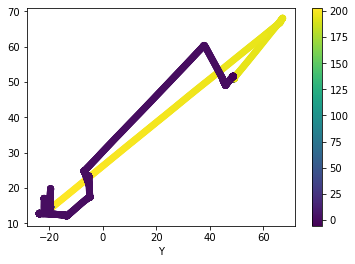

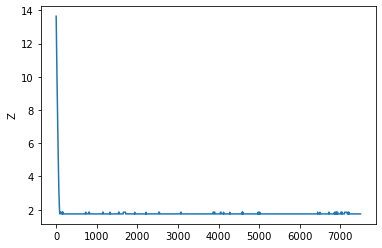

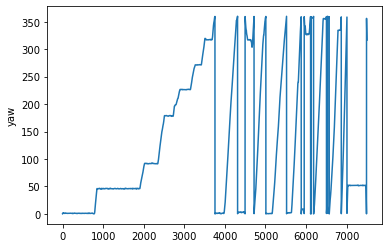

In [14]:
plt.scatter(dronedata.coords_xyz_LC[:,0],dronedata.coords_xyz_LC[:,1],c=dronedata.coords_xyz_LC[:,2])
plt.xlabel('X')
plt.xlabel('Y')
plt.colorbar()
plt.show()

plt.plot(dronedata.coords_xyz_LC[sti:sto,2])
plt.ylabel('Z')
plt.show()

plt.plot(dronedata.yaw[sti:sto])
plt.ylabel('yaw')
plt.show()



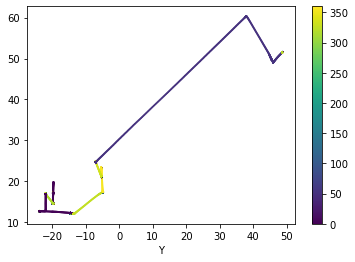

In [13]:
sti=2500
sto=10000
plt.scatter(dronedata.coords_xyz_LC[sti:sto,0],dronedata.coords_xyz_LC[sti:sto,1],
            c=dronedata.yaw[sti:sto],s=1)
plt.xlabel('X')
plt.xlabel('Y')
plt.colorbar()
plt.show()

0 0.0
1 -48.5
2 -232.0
3 -11.0
4 0.0
5 11924.5
6 85.0
7 0.0
8 8213.5
9 0.0


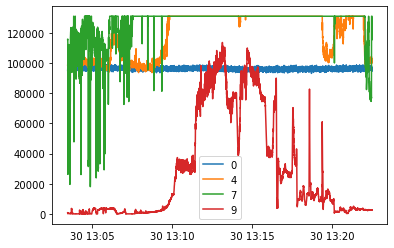

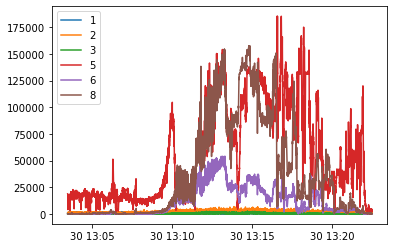

In [15]:
for i in np.arange(0,10):
    print(i, np.median(corrdata.V[:,f_ind,i].imag))

# autos are on 0,4,7,9
# crosses are 1,2,3; 5, 6; 8


for i in [0,4,7,9]:#np.arange(0,10): 
    plt.plot(corrdata.t_arr_datetime,corrdata.V[:,f_ind,i].real,label=str(i))#'real')
    #plt.plot(corrdata.t_arr_datetime,corrdata.V[:,f_ind,i].imag,label='imag')
    plt.legend()
plt.show()

for i in [1,2,3,5,6,8]:#np.arange(0,10): 
    plt.plot(corrdata.t_arr_datetime,abs(corrdata.V[:,f_ind,i]),label=str(i))#'real')
    #plt.plot(corrdata.t_arr_datetime,corrdata.V[:,f_ind,i].imag,label='imag')
    plt.legend()
plt.show()

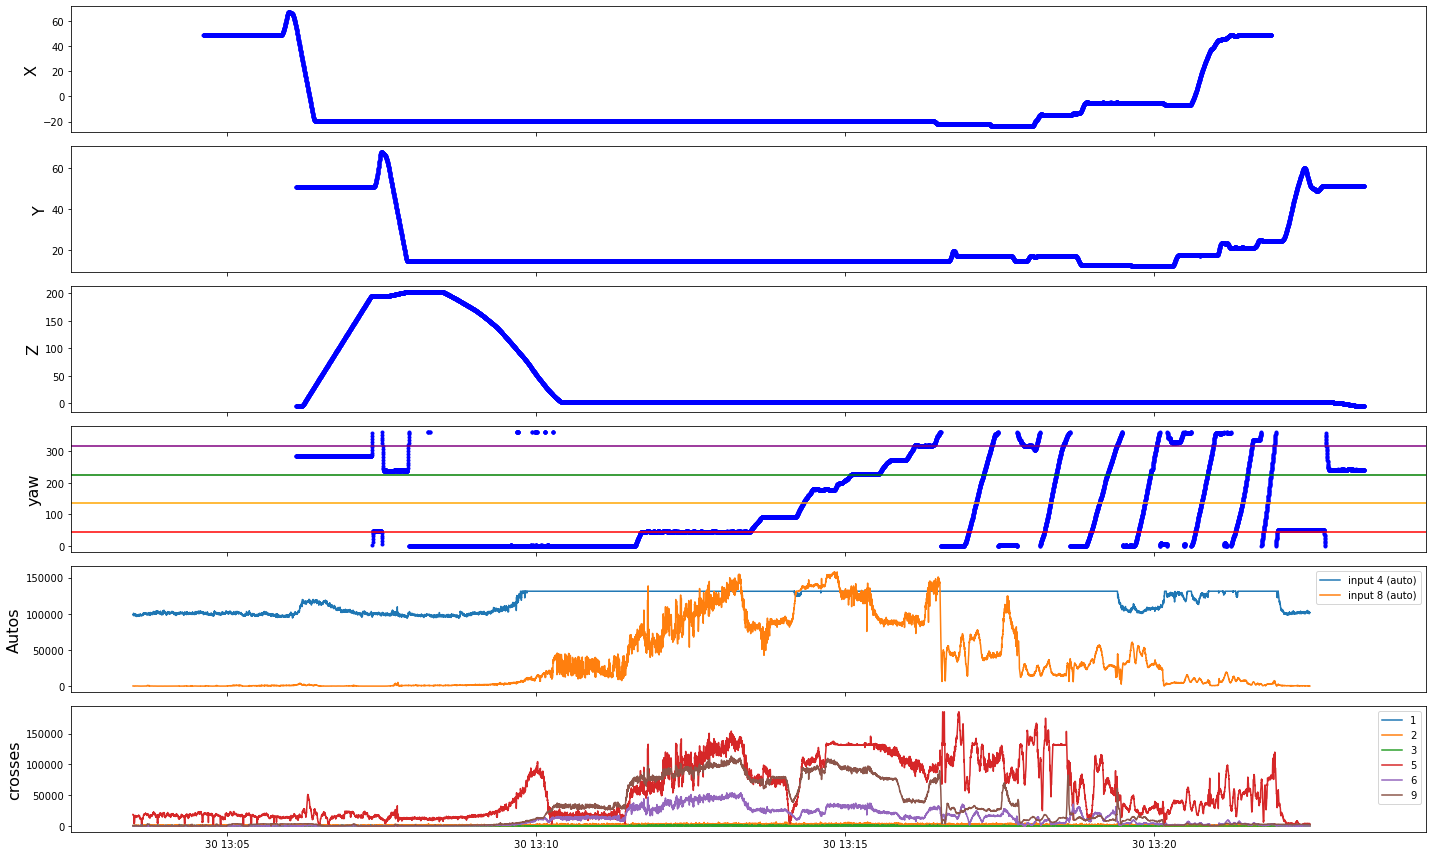

In [19]:
addtime=-3.5*60


fig, (ax1, ax2,ax3,ax4,ax5,ax6) = plt.subplots(nrows=6, ncols=1, sharex=True,figsize=(20, 12))

# Plot data on each axis
ax1.plot(dronedata.t_arr_datetime + datetime.timedelta(seconds=-5*60),dronedata.coords_xyz_LC[:,0],'b.')
ax1.set_ylabel('X',fontsize=16)

ax2.plot(dronedata.t_arr_datetime + datetime.timedelta(seconds=addtime),dronedata.coords_xyz_LC[:,1],'b.')
ax2.set_ylabel('Y',fontsize=16)

ax3.plot(dronedata.t_arr_datetime + datetime.timedelta(seconds=addtime),dronedata.coords_xyz_LC[:,2],'b.')
ax3.set_ylabel('Z',fontsize=16)

ax4.plot(dronedata.t_arr_datetime + datetime.timedelta(seconds=addtime),dronedata.yaw,'b.')
ax4.axhline(45,color='red')
ax4.axhline(135,color='orange')
ax4.axhline(225,color='green')
ax4.axhline(315,color='purple')
ax4.set_ylabel('yaw',fontsize=16)

#ax5.plot(corrdata.t_arr_datetime,np.abs(corrdata.V[:,f_ind,8]),label='input 8 (cross)')
ax5.plot(corrdata.t_arr_datetime,np.abs(corrdata.V[:,f_ind,4]),label='input 4 (auto)')
ax5.plot(corrdata.t_arr_datetime,np.abs(corrdata.V[:,f_ind,8]),label='input 8 (auto)')
ax5.set_ylabel('Autos',fontsize=16)
ax5.legend()

for i in [1,2,3,5,6,9]:#np.arange(0,10): 
    ax6.plot(corrdata.t_arr_datetime,abs(corrdata.V[:,f_ind,i]),label=str(i))#'real')
    #plt.plot(corrdata.t_arr_datetime,corrdata.V[:,f_ind,i].imag,label='imag')
    ax6.legend()
ax6.set_ylabel('crosses',fontsize=16)  
    

plt.tight_layout()
plt.show()



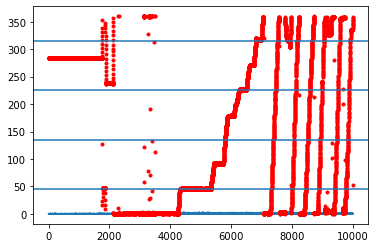

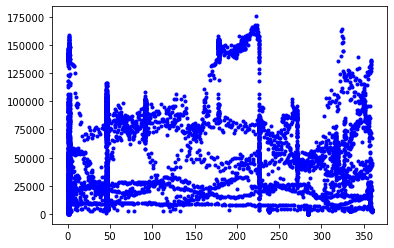

In [116]:
# interpolate drone time stamps to data time stamps:

addtime=-4.5*60

sti = 0
sto = 10000
corr_tstamp = [d.timestamp() for d in corrdata.t_arr_datetime]

drone_tstamp = [d.timestamp() for d in dronedata.t_arr_datetime + datetime.timedelta(seconds=addtime)]

drone_yaw_interp = np.interp(corr_tstamp, 
                           drone_tstamp, 
                           dronedata.yaw)

plt.plot(np.abs(corrdata.V[sti:sto,f_ind,2])*5E-4)
plt.plot(drone_yaw_interp[sti:sto],'r.')
plt.axhline(45)
plt.axhline(135)
plt.axhline(225)
plt.axhline(315)
plt.show()

plt.plot(drone_yaw_interp[sti:sto],np.abs(corrdata.V[sti:sto,f_ind,8]),'b.')
plt.show()

#plt.plot(drone_yaw_interp,np.abs(corrdata.V[:,f_ind,9]))

In [108]:
concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False,t_drone_offset=-240)#-244.75)


AttributeError: 'Corr_Data' object has no attribute 'crossmap'

In [ ]:
for j in np.arange(0,len(crmap)):
    plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],c=np.abs(concatdata.V_cross[:,f_ind,j]))
    plt.colorbar()
    plt.xlabel('X [m]')
    plt.ylabel('Y [m]')
    plt.title(chnames[j])
    plt.show()

## 1. Find Correspondence between drone flight file and correlator data

In [ ]:
# I'm putting this all in one cell (which won't run) now that the numbers are all stored

## 2. Capture in the yaml file - then can run everything below without above
#(Once it is in a yaml file, the above cells do not need to be run)

In [ ]:
with open('../metadata/DNS_GBO_flights_forscripts_LBN.yaml', 'r') as fff:
    documents = yaml.safe_load(fff)
flights = documents["flight_info"]["flights"]
descrip = documents["flight_info"]["desc"]

for f,fly in enumerate(flights):
    fly = flights[f]
    tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
    tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
    cdat = documents["flight_info"]["cdats"][f]
    tclb = documents["flight_info"]["tclbs"][f]
    tcub = documents["flight_info"]["tcubs"][f]
    fmax = documents["flight_info"]["fmaxes"][f]
    fmin = documents["flight_info"]["fmins"][f]
    descrip = documents["flight_info"]["desc"][f]
    pols = documents["flight_info"]["pols"][f]
    print(fly, cdat, tlb, tub, tclb, tcub, fmin,fmax,descrip,pols)

# airdata files are not very easily subscriptable, 
# cluge for now by knowing which flight order is in the yaml
f = 5


fly = flights[f]
tub = documents["flight_info"]["tubs"][f] # this is lowest interesting index in drone data
tlb = documents["flight_info"]["tlbs"][f] # this is highest interesting index in drone data
cdat = documents["flight_info"]["cdats"][f]
tclb = documents["flight_info"]["tclbs"][f]
tcub = documents["flight_info"]["tcubs"][f]
fmax = documents["flight_info"]["fmaxes"][f]
fmin = documents["flight_info"]["fmins"][f]


ddir = cdir+cdat+'/corr/'
di = os.listdir(ddir)[0]
datadir = ddir+str(di)+'/'
gaindir = gdir+cdat+'_digitalgain/'
print('Using data directory: ',datadir)
print('Using gain directory: ',gaindir)

print(fly, tub, tlb, tclb, tcub, cdat,fmin,fmax)

In [ ]:
dronedata=drone.Drone_Data(Drone_Directory=dronedir,FLYTAG=fly,site_class=gbosite,tlb=tlb,tub=tub)

print('DONE reading in drone data')
print(dronedata.t_arr_datetime[0], dronedata.t_arr_datetime[-1])

plt.plot(dronedata.t_arr_datetime,'b.',label='drone')
plt.show()

pu.Plot_Drone_Coordinates(dronedata,coo='xy')#,t_bounds=[tlb,tub])
#pu.Plot_Drone_Coordinates(dronetest0825,coo='xy',t_bounds=[tlb,tub])

In [ ]:
## Combine drone and correlator data
print('start time: ', datetime.datetime.now())

corrdata=corr.Corr_Data(Data_Directory=datadir,
                    Gain_Directory=gaindir,site_class=gbosite,
                    Load_Gains=True,use_ctime=True,
                    crossmap=crmap,Data_File_Index=[int(fmin),int(fmax)])

#corrdata=corr.Corr_Data(Data_Directory=datadir,
#                    Gain_Directory=gaindir,site_class=gbosite,
#                    Load_Gains=True,use_ctime=True,
#                    crossmap=crmap,Data_File_Index=[int(fmin),int(fmin)+1])


    
print('end time: ', datetime.datetime.now())

## plot their datetime arrays to check overlap:

plot(dronedata.t_arr_datetime,label='drone')
plot(corrdata.t_arr_datetime,label='data')
legend()


In [ ]:
# Match drone and correlator data together, and plot a few frequencies

concatdata=concat.CONCAT(CORRDATCLASS=corrdata,DRONEDATCLASS=dronedata,\
                             load_yaml=False,traceback=False,save_traceback=False)


In [ ]:
## Bunches of plots to quickly look at the data
plotthis = False

if plotthis:
    print('Beam maps without any time correction or pulse calculation')
    for j in np.arange(0,len(crmap)):
        plt.scatter(concatdata.drone_xyz_LC_interp[:,0],concatdata.drone_xyz_LC_interp[:,1],
                c=abs(concatdata.V_cross[:,f_ind,j]))
        plt.colorbar()
        plt.xlabel('X [m]')
        plt.ylabel('Y [m]')
        plt.title(chnames[j])
        plt.show()
    
    print('Plot the gains')
    # lets check gain application
    print(gaindir)
    gainfile=os.listdir(gaindir)[0]
    fg = h5py.File(gaindir+gainfile, 'r')
    gain_coeffs=fg['gain_coeff'][0] 
    gain_exp=fg['gain_exp'][0]
    digital_gain=fg['gain_coeff'][0] 
    digital_gain*=np.power(2,fg['gain_exp'][0])[np.newaxis,:]

    for j in np.arange(0,len(digital_gain[0,:])):
        plt.semilogy(freqs,digital_gain[:,j],label=str(j))
    plt.legend()
    plt.show()

    # plot waterfalls 

    print('Plotting waterfalls of autocorrelations')
    # waterfall of autos
    vmin=-100
    vmax=-92
    for j in autos:
        fig=figure(figsize=(16,8))
        plt.imshow(10*np.log10(abs(concatdata.V_cross[:,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()
    
    print('plotting waterfalls of dish x reference')
    # waterfall of crosses
    vmin=-140
    vmax=-100
    for j in crosses:
        fig=figure(figsize=(16,8))
        plt.imshow(10*np.log10(abs(concatdata.V_cross[:,:,j])),aspect='auto',vmin=vmin,vmax=vmax)
        #plt.xlim(tclb,tcub)
        plt.title(chnames[j])
        plt.colorbar()
        plt.show()

In [ ]:
print(concatdata.V.shape)

In [ ]:
## OBJECTIVE 5A: concat Function: Extract_Source_Pulses

## Let's use the Extract_Source_Pulses function:
    # The Period and Dutycycle options are known beforehand, and given in microseconds.
    # The t_bounds option just determines the plot bounds, not the solving routine.
## Fortunately, these parameters are loaded from the config, so we don't have to wait for the solver to run.
    ## The returned t_delta_pulse parameter will be given in seconds.
    ## In the verification plot, we should see the following points plotted:
        # orange_o = inds_off  = times when the source is off
        # blue_o   = inds_on   = times when the source is on and broadcasting
        # green_x  = inds_span = times where the behavior changes during the integration period (omit always!)
    ## The print statements shows the list of indices that appear in more than one of on/off/span.
        ## If they are all empty lists [], then there is no overlap which is a good thing.
concatdata.traceback=False
print('start time: ', datetime.datetime.now())
concatdata.Extract_Source_Pulses(Period=0.99999e6,Dutycycle=0.5e6,t_bounds=[0,-1],f_ind=f_ind, use_ref_channel=3)

print('end time: ', datetime.datetime.now())

In [ ]:
# aside to look at the span, on, and off indices in more detail

chind = 6
t_cut = concatdata.inds_on
t_span = concatdata.inds_span
t_off = concatdata.inds_off
N = len(t_cut)
N2 = int(N/2)
print(len(t_cut),len(t_span),len(t_off))
plt.figure(1,figsize=(10,10))

plt.plot(concatdata.t_arr_datetime[t_cut],concatdata.V_cross[t_cut,f_ind,chind],'b.',label='on')
plt.plot(concatdata.t_arr_datetime[t_span],concatdata.V_cross[t_span,f_ind,chind],'gx',label='span')
plt.plot(concatdata.t_arr_datetime[t_off],concatdata.V_cross[t_off,f_ind,chind],'r.',label='off')
plt.xlim(concatdata.t_arr_datetime[t_cut[N2]],concatdata.t_arr_datetime[t_cut[N2+300]])
plt.legend()
plt.show()

In [ ]:
## OBJECTIVE 5B: concat Function: Perform_Background_Subtraction

## Let's do background subtraction: creates computed background (V_bg) and background-subtracted (V_bgsub) arrays:
    # window_size=5 - this is 1/2 the width of the 'index window' across which the background is averaged.
    # This function only works if the source was pulsed and Extract_Source_Pulses was used!
concatdata.Perform_Background_Subtraction(window_size=15)

In [ ]:
print(concatdata.V_cross.shape)
print(concatdata.V_bgsub.shape)
print(concatdata.V_cross_bgsub.shape)
print(f_ind)
print(concatdata.t_index)

chind=0
print(abs(concatdata.V_cross[t_cut,f_ind,chind]))
print(abs(concatdata.V_cross[t_off,f_ind,chind]))
print(concatdata.V_cross_bgsub[t_cut,f_ind,chind])

nan_count_numpy = np.count_nonzero(np.isnan(concatdata.V_cross_bgsub[t_cut,f_ind,chind]))
print(f"NaN count in NumPy array: {nan_count_numpy}")

In [ ]:
for chind in np.arange(0,len(crmap)):
    fig=figure(figsize=(8,4))
    plt.plot(concatdata.t_arr_datetime[t_cut],10*np.log10(abs(concatdata.V_cross_bgsub[t_cut,f_ind,chind])),'b.')
    #plt.xlim(tclb,tcub)
    plt.title('REAL '+chnames[chind] + ' Freqind: '+str(f_ind)+' Freq: '+str(freqs[f_ind]))
    #plt.xlim(plb,pub)
    plt.legend()
    plt.show()


In [ ]:
# waterfall of autos
print('Plotting waterfalls of autocorrelations')
# waterfall of autos

for chind in autos:
    print(chind)
    fig=figure(figsize=(16,8))
    plt.scatter(concatdata.drone_xyz_LC_interp[t_cut,0],concatdata.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concatdata.V_cross_bgsub[t_cut,f_ind,chind]),s=10.0,
            cmap='gnuplot2')
    #plt.xlim(tclb,tcub)
    plt.title(chnames[chind])
    plt.colorbar()
    plt.show()

#print('plotting waterfalls for crosses')
## waterfall of crosses
#vmin=-140
#vmax=-100
#for chind in crosses:
#    fig=figure(figsize=(16,8))
#    plt.imshow(10*np.log10(abs(concatdata.V_cross[t_cut,:,chind])),aspect='auto',vmin=vmin,vmax=vmax)
#    #plt.xlim(tclb,tcub)
#    plt.title(chnames[chind])
#    plt.colorbar()
#    plt.show()

In [ ]:
chind = 0
fig=figure(figsize=(16,8))
plt.scatter(concatdata.drone_xyz_LC_interp[t_cut,0],concatdata.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concatdata.V_bgsub[t_cut,f_ind,chind]),s=10.0,
            cmap='gnuplot2')
#plt.xlim(tclb,tcub)
plt.title(chnames[chind])
plt.colorbar()
plt.show()

In [ ]:
## OBJECTIVE 5C: concat Function: Synchronization_Function

## This function finds the absolute timing shift between the dji data from the drone and the correlator
    ## We will be loading t_delta_dji from the config file to save some time!
    ## This function only works if the source was pulsed and if V_bgsub was created using background subtraction.
    ## This function works by zooming into the gaussian main beam and removing saturated data points...
## To run, you must give the following:
    ## inputcorr  = the corr class used in the concat
    ## inputdrone = the drone class used in the concat
## The optional parameters and their default values are listed below:
    ## coarse_params=[-10.0,10.0,0.2]    = the min,max,step parameters for the coarse time offset array
    ## fine_params=[-0.5,0.5,0.01]       = the min,max,step parameters for the fine time offset array
    ## chans=np.arange(0,2)              = the channels to fit. 0,1 gives us each polarization
    ## freqs=np.arange(100,1024,150)     = the min,max,step parameters for the freq array axis
    ## FMB_coordbounds=[50.0,50.0,150.0] = the cartesian coords we restrict around the main beam
        # x within +/- 50m from dish center in Local Cartesian (LC)
        # y within +/- 50m from dish center in Local Cartesian (LC)
        # z > 150m from dish center in Local Cartesian (LC)
    ## FMB_ampbound=0.999                = amplitude percentile threshold for saturation... 
        # time indices where the amplitude exceeds 0.999*maximum value are excluded because they are saturated

concatdata.Synchronization_Function(inputcorr=corrdata,inputdrone=dronedata,
                                        coarse_params=[-20.0,20.0,1],
                                        chans=np.array([0,1]),freqs=np.arange(304,305,1),
                                        FMB_coordbounds=[80.0,80.0,150.0],
                                        FMB_ampbound=0.999)

## Since we are loading from the config, we get to skip an iterative loop and just take the solution and apply it.
    ## The verification plot shown is hidden when traceback==False is set in the concat initialization
    ## Look closely at the verification plots to see which channel appears to be the co-pol (channel 1)
    ## In the bottom 2 panels, compare the fit result (white gaussian) to the data points (in color)
        ## We are omitting the saturated points to find the REAL max value, instead of squashing our peak
        ## If we are satisfied with this fit, we should try to save the parameters we found...

In [ ]:
print(concatdata.t_delta_dji)

In [ ]:
for chind in [0,1,2,3]:#np.arange(0,len(crmap)):
    plt.scatter(concatdata.drone_xyz_LC_interp[t_cut,0],concatdata.drone_xyz_LC_interp[t_cut,1],
            c=10*np.log10(concatdata.V_cross_bgsub[t_cut,f_ind,chind]),s=1.0,
            cmap='gnuplot2')
    #plt.xlim(-50,0)
    #plt.ylim(-20,40)
    plt.colorbar()
    plt.show()

In [ ]:
# Do this to correct for 1/r^2 dependence

#concattest0825.Distance_Compensation(f_ind=900,plot_channels=[0])

In [ ]:
## OBJECTIVE 5D: concat Function: Export_yaml

## When we have results we want to save, we should export our results to a config file for future use:
    ## The file will be written to the directory stated when the concat class was initialized.
    ## If a concat config yaml file already exists, a new version will be saved.
## Uncomment this if you want to export a config file... 


#concatdata5.Export_yaml()

In [ ]:
## OBJECTIVE 5E: concat Function: Main_Beam_Fitting

## Now we can do some analysis, since we have synchronized useful data. We can begin by fitting the main beam:
    ## You can specify the directory where you want the fit params to be output:
    ## fit_param_directory='/hirax/GBO_Analysis_Outputs/main_beam_fits/'
    ## This one sometimes takes a while, feel free to get a coffee or something.
concatdata.Main_Beam_Fitting(fit_param_directory=maindir+'main_beam_fits/',freqs=np.arange(0,512,1),
                                 coordbounds=[80.0,80.0,150.0],
                                 FMB_ampbound=0.999,
                                 Vargs='bgsub')

print(concatdata.G_popt.shape)

In [ ]:
print(concatdata.G_popt[0,f_ind,:])

In [ ]:
plotthis = False

if plotthis:
    if concatdata.traceback==True:
        # copy and paste the file list above to make a plot
        ## this is your first glance at whether the Gaussian fits make sense across frequency for all channels
        ## these are grouped by polarization: small dots are one pol, big dots are the other
        filelist=['FLY648_20211022T191922Z_ver_20231012T160758_2dGauss_and_Airy_Params.npz']
        pu.plot_MBG_fits(filelist,cmp='gnuplot2')
    
    markers = ['s','v','^','>','P','x','+','o']
    colors=['red','orange','yellow','green','blue','purple','pink']

    fits = np.load('/hirax/GBO_Analysis_Outputs/main_beam_fits/FLY648_20211022T191922Z_ver_20231012T160758_2dGauss_and_Airy_Params.npz')
    pols=[0,2,8,10,14]
    freqs = np.arange(800,400,-400/1024)

    # amp
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,0],markersize=4,color=colors[pp],label=str(p))
    plt.title('Amplitude')
    plt.legend()
    plt.ylim(0,1.5E-7)
    plt.show()

    # X width
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,2],markersize=4,marker='.',color=colors[pp],linestyle='None',label=str(p))
    plt.title('X width')
    plt.legend()
    plt.ylim(4,15)
    plt.show()

    # Y width
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,4],markersize=4,marker='.',linestyle='None',color=colors[pp],label=str(p))
    plt.title('Y width')
    plt.legend()
    plt.ylim(4,17)
    plt.show()

    # X center
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,1],markersize=4,color=colors[pp],label=str(p))
    plt.title('X center')
    plt.legend()
    #plt.ylim(4,14)
    plt.show()

    # Y center
    fig = plt.figure(figsize=(8,6))
    for pp,p in enumerate(pols):
        plt.plot(freqs,fits['G_popt'][p,:,3],markersize=4,color=colors[pp],label=str(p))
    plt.title('Y center')
    plt.legend()
    #plt.ylim(4,14)
    plt.show()


In [ ]:
# write out to a pickle file, name is autogenerated in the Smallify class

thingy = rc.Smallify(concatdata,pickle_directory=maindir)
print(thingy.tmppath)
with open(thingy.tmppath, 'wb') as outp:
    pickle.dump(thingy, outp, pickle.HIGHEST_PROTOCOL)
print('DONE')

In [ ]:
radfile = thingy.tmppath
print('Loading: ',radfile)
with open(radfile, 'rb') as inp:
    ptest = pickle.load(inp)



In [ ]:
for chind in np.arange(0,len(crmap)):
    plt.scatter(ptest.drone_xyz_LC_interp[ptest.inds_on,0],ptest.drone_xyz_LC_interp[ptest.inds_on,1],
               c=10*np.log10(ptest.V_cross_bgsub[ptest.inds_on,f_ind,chind]), cmap='gnuplot2')
    plt.colorbar()
    plt.show()
